<a href="https://colab.research.google.com/github/Rahulshanth/loan_approval_model/blob/main/Final_Python_Notebook_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python Notebook 3 – Ensemble Voting Classifier & Regression Decision Trees

**Module:** 5DATA002W.2 – Machine Learning & Data Mining  
**University:** University of Westminster  
**Author:** [Your Full Name]  
**Student ID:** [Your Student ID]  
**Code Peer Reviewer:** [Peer Reviewer Full Name]  
**Peer Review Date:** [Date of Peer Review]  

---

## Notebook Overview

This notebook covers **two** tasks:

**Part A – Ensemble Voting Classifier:** A probability-based (soft) voting ensemble classifier is built by combining two base learners – Naïve Bayes (NB) and Logistic Regression (LR) – from Python Notebook 2, to predict Loan Approval Status.

**Part B – Regression Decision Trees:** A fully grown Decision Tree Regressor (DT-1) and a pruned Decision Tree Regressor limited to 4 levels (DT-2) are built to predict the Maximum Loan Amount for loan-approved clients.

---
# PART A: Ensemble Voting Classifier – Loan Approval Status

**Research Question (a):** Does machine learning have the potential to automate loan approval decisions for the company?

## Step 1 – Import Libraries

**Code Reuse Reference – Code Reuse Session 3:**  
Library import blocks – `from sklearn.naive_bayes import MultinomialNB` (adapted to `GaussianNB`), `from sklearn.linear_model import LogisticRegression`, `from sklearn.ensemble import VotingClassifier`, `from sklearn.metrics import confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`, `RocCurveDisplay`, `from sklearn.model_selection import train_test_split`, and `from sklearn.tree import DecisionTreeRegressor` blocks.  
Also references *Seminar Session (Tutorial 6, 7, 8, 9)* library blocks.

In [1]:
# Import pandas library for loading and working with datasets
import pandas as pd

# Import numpy for numerical array operations
import numpy as np

# Import matplotlib for plotting graphs and trees
import matplotlib.pyplot as plt

# Import train_test_split to divide data into training and testing subsets
from sklearn.model_selection import train_test_split

# Import GaussianNB – the same Naive Bayes used in Python Notebook 2
# GaussianNB is used instead of MultinomialNB from the code block because
# the features are continuous (normalised 0-1 by MinMaxScaler in Notebook 1),
# not discrete counts, so GaussianNB is the correct choice
from sklearn.naive_bayes import GaussianNB

# Import LogisticRegression – same model used in Python Notebook 2
from sklearn.linear_model import LogisticRegression

# Import VotingClassifier to build the ensemble model
from sklearn.ensemble import VotingClassifier

# Import DecisionTreeRegressor for building regression decision trees in Part B
from sklearn.tree import DecisionTreeRegressor

# Import the tree module to visualise decision trees
from sklearn import tree

# Import metrics module for regression evaluation metrics
from sklearn import metrics

# Import confusion_matrix to evaluate classification performance
from sklearn.metrics import confusion_matrix

# Import ConfusionMatrixDisplay to plot the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Import classification_report for precision, recall, F1 and accuracy per class
from sklearn.metrics import classification_report

# Import RocCurveDisplay to plot the AUC-ROC curve
from sklearn.metrics import RocCurveDisplay

# Import individual metric functions for summary comparison table
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Confirm all imports loaded without error
print('All libraries imported successfully.')

All libraries imported successfully.


## Step 2 – Load the Classification Dataset

**Code Reuse Reference – Code Reuse Session 3:**  
`pd.read_csv(...)` and `df.describe(include='all').transpose()` code blocks.  
Also references *Code Reuse Session 1* and *Tutorial 6* dataset loading blocks.

The `loan_classification_dataset.csv` file was prepared and saved in Python Notebook 1. It contains all loan applicants (approved and rejected) with features cleaned, label-encoded, and normalised using MinMaxScaler.

In [2]:
# Suppress scientific notation so numbers display clearly
pd.set_option('display.float_format', '{:.4f}'.format)

# Load the prepared classification dataset saved from Python Notebook 1
data = pd.read_csv('loan_classification_dataset.csv')

# Print confirmation of load and dataset dimensions
print('Classification dataset loaded successfully.')
print('Shape (rows, columns):', data.shape)

# Display the first 5 rows to confirm the dataset structure
data.head()

Classification dataset loaded successfully.
Shape (rows, columns): (58618, 11)


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,0.0156,0.0041,2,0.0000,1,0.4203,0.0882,0.1446,0,0.0714,0
1,0.0156,0.0047,2,0.0488,1,0.7101,0.6376,0.2289,1,0.0357,0
2,0.0469,0.0028,3,0.1220,3,0.8551,0.3933,0.3735,0,0.0357,0
3,0.3125,0.0938,3,0.0732,1,1.0000,0.1449,0.2289,0,0.3214,0
4,0.3125,0.0453,0,0.0732,2,1.0000,0.3933,0.4699,0,0.4286,0


In [3]:
# Display column names and data types to confirm encoding and scaling from Notebook 1
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58618 entries, 0 to 58617
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      58618 non-null  float64
 1   income                   58618 non-null  float64
 2   home_ownership           58618 non-null  int64  
 3   emplyment_length         58618 non-null  float64
 4   loan_intent              58618 non-null  int64  
 5   loan_amount              58618 non-null  float64
 6   loan_interest_rate       58618 non-null  float64
 7   loan_income_ratio        58618 non-null  float64
 8   payment_default_on_file  58618 non-null  int64  
 9   credit_history_length    58618 non-null  float64
 10  loan_approval_status     58618 non-null  int64  
dtypes: float64(7), int64(4)
memory usage: 4.9 MB


In [4]:
# Display descriptive statistics for all columns to understand the data distribution
data.describe(include='all').transpose()

,count,mean,std,min,25%,50%,75%,max
age,58618.0000,0.1180,0.0941,0.0000,0.0469,0.0938,0.1562,1.0000
income,58618.0000,0.0316,0.0200,0.0000,0.0199,0.0284,0.0377,1.0000
home_ownership,58618.0000,1.6735,1.4525,0.0000,0.0000,3.0000,3.0000,3.0000
emplyment_length,58618.0000,0.1146,0.0951,0.0000,0.0488,0.0976,0.1707,1.0000
loan_intent,58618.0000,2.5196,1.7229,0.0000,1.0000,3.0000,4.0000,5.0000
loan_amount,58618.0000,0.2527,0.1613,0.0000,0.1304,0.2174,0.3333,1.0000
loan_interest_rate,58618.0000,0.2954,0.1705,0.0000,0.1382,0.2994,0.4253,1.0000
loan_income_ratio,58618.0000,0.1918,0.1105,0.0000,0.1084,0.1687,0.2530,1.0000
payment_default_on_file,58618.0000,0.1484,0.3555,0.0000,0.0000,0.0000,0.0000,1.0000
credit_history_length,58618.0000,0.1362,0.1439,0.0000,0.0357,0.0714,0.2143,1.0000


## Step 3 – Define Input Features and Target Variable

**Code Reuse Reference – Code Reuse Session 3:**  
`X = df.drop(['loan_approval_status'], axis=1)` drop syntax block.  
Also references *Code Reuse Session 2* feature selection block.

The same 10 input features and target used in Python Notebook 2 are applied here to ensure consistent results across notebooks.

In [5]:
# List all input feature columns – must match exactly what was used in Notebook 2
# loan_approval_status is the target so it is excluded from the feature list
feature_cols = ['age', 'income', 'home_ownership', 'emplyment_length',
                'loan_intent', 'loan_amount', 'loan_interest_rate',
                'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

# Assign the input features to X
X = data[feature_cols]

# Assign the target variable (loan approval status) to y
y = data['loan_approval_status']

# Print feature names and shapes as evidence (required by the report)
print('Feature names used for classification models:')
print(feature_cols)
print()
print('Shape of X (features):', X.shape)
print('Shape of y (target)  :', y.shape)
print()
# Show class distribution in the target variable
print('Class distribution in target variable (loan_approval_status):')
print(y.value_counts())
print()
print('0 = Rejected | 1 = Approved')

Feature names used for classification models:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

Shape of X (features): (58618, 10)
Shape of y (target)  : (58618,)

Class distribution in target variable (loan_approval_status):
loan_approval_status
0    50273
1     8345
Name: count, dtype: int64

0 = Rejected | 1 = Approved


## Step 4 – Training and Test Split

**Code Reuse Reference – Code Reuse Session 3:**  
`train_test_split(X, y, test_size=value, random_state=value, stratify=y)` code block.

**Identical parameters to Python Notebook 2 are used:**  
`test_size=0.20`, `random_state=42`, `stratify=y`.  
- `random_state=42` ensures all three models (NB, LR, Ensemble) are tested on the **same** test instances as in Notebook 2.  
- `stratify=y` ensures the Approved/Rejected class ratio is preserved in both training and test subsets.

In [6]:
# Split the data into 80% training and 20% testing subsets
# random_state=42 – same as Notebook 2, guarantees same test instances for all models
# stratify=y – preserves the Approved/Rejected class ratio in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Print the resulting sizes to confirm the split
print('Training set size:', X_train.shape[0], 'rows')
print('Test set size    :', X_test.shape[0], 'rows')
print()

Training set size: 46894 rows
Test set size    : 11724 rows



In [7]:
# Confirm stratification – check the class distribution in the training set
print('Class distribution in TRAINING set:')
print(y_train.value_counts())
print()

# Confirm stratification – check the class distribution in the test set
print('Class distribution in TEST set:')
print(y_test.value_counts())

Class distribution in TRAINING set:
loan_approval_status
0    40218
1     6676
Name: count, dtype: int64

Class distribution in TEST set:
loan_approval_status
0    10055
1     1669
Name: count, dtype: int64


## Step 5 – Base Learner 1: Naïve Bayes (NB)

**Code Reuse Reference – Code Reuse Session 3:**  
Base Learner 1 (Naïve Bayes) block: `from sklearn.naive_bayes import MultinomialNB` (adapted to `GaussianNB` – see note below), `nb = MultinomialNB()`, `nb = nb.fit(X_train, y_train)`, `y_pred_nb = nb.predict(X_test)`, `confusion_matrix`, `ConfusionMatrixDisplay`, `disp.plot()`, `classification_report`, and `RocCurveDisplay.from_estimator(...)` blocks.

**Note on GaussianNB:** The code block provides `MultinomialNB`, however the classification dataset contains continuous, normalised (0–1) features. `MultinomialNB` is designed for discrete non-negative counts (Manning et al., 2008). `GaussianNB` assumes a Gaussian distribution of continuous features and is therefore the correct variant. This is the same model built in Python Notebook 2.

In [8]:
# Instantiate the Gaussian Naive Bayes model – same as Python Notebook 2
nb = GaussianNB()

# Fit the NB model on the training data
nb.fit(X_train, y_train)

# Predict loan approval status on the test set
y_pred_nb = nb.predict(X_test)

# Print confirmation that the model has been trained
print('Naive Bayes model fitted and predictions generated.')

Naive Bayes model fitted and predictions generated.


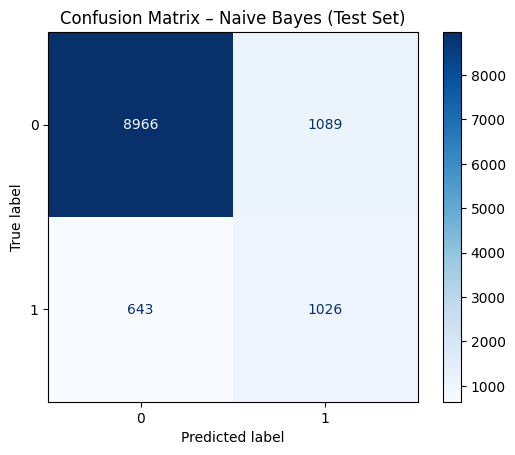

In [9]:
# Compute the confusion matrix for Naive Bayes test predictions
nb_cm = confusion_matrix(y_test, y_pred_nb, labels=nb.classes_)

# Create a ConfusionMatrixDisplay object with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=nb_cm, display_labels=nb.classes_)

# Plot the confusion matrix for Naive Bayes
disp.plot(cmap='Blues')

# Set the title for the confusion matrix plot
plt.title('Confusion Matrix – Naive Bayes (Test Set)')

# Display the plot
plt.show()

In [10]:
# Print the full classification report for the Naive Bayes model
print('Classification Report – Naive Bayes (Test Set)')
print(classification_report(y_test, y_pred_nb))

Classification Report – Naive Bayes (Test Set)
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     10055
           1       0.49      0.61      0.54      1669

    accuracy                           0.85     11724
   macro avg       0.71      0.75      0.73     11724
weighted avg       0.87      0.85      0.86     11724



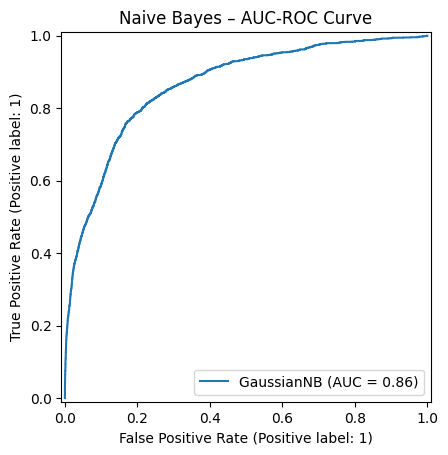

In [11]:
# Plot the AUC-ROC curve for the Naive Bayes model
# RocCurveDisplay.from_estimator uses predict_proba to get probability scores
RocCurveDisplay.from_estimator(nb, X_test, y_test)

# Set the title for the Naive Bayes ROC curve
plt.title('Naive Bayes – AUC-ROC Curve')

# Display the ROC curve
plt.show()

## Step 6 – Base Learner 2: Logistic Regression (LR)

**Code Reuse Reference – Code Reuse Session 3:**  
Base Learner 2 (Logistic Regression) block: `from sklearn.linear_model import LogisticRegression`, `lr = LogisticRegression()`, `lr = lr.fit(X_train, y_train)`, `y_pred_lr = lr.predict(X_test)`, `confusion_matrix`, `ConfusionMatrixDisplay`, `disp.plot()`, `classification_report`, and `RocCurveDisplay.from_estimator(...)` blocks.

The same Logistic Regression configuration from Python Notebook 2 is used (`max_iter=1000`, `random_state=42`) to ensure result consistency.

In [12]:
# Instantiate the Logistic Regression model – same configuration as Python Notebook 2
# max_iter=1000 ensures the solver converges on this dataset
logreg = LogisticRegression(max_iter=1000)

# Fit the Logistic Regression model on the training data
logreg.fit(X_train, y_train)

# Predict loan approval status on the test set
y_pred_lr = logreg.predict(X_test)

# Print confirmation
print('Logistic Regression model fitted and predictions generated.')

Logistic Regression model fitted and predictions generated.


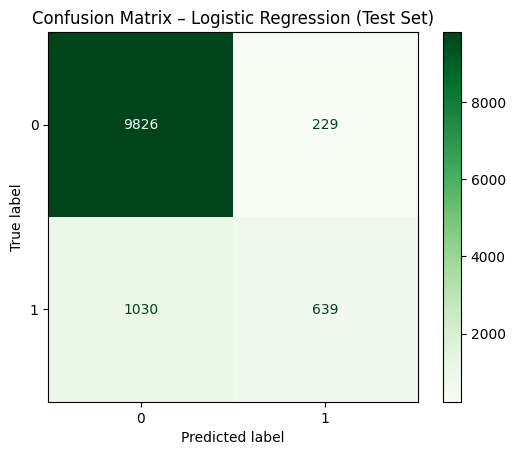

In [13]:
# Compute the confusion matrix for Logistic Regression test predictions
lr_cm = confusion_matrix(y_test, y_pred_lr, labels=logreg.classes_)

# Create a ConfusionMatrixDisplay object for Logistic Regression
disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm, display_labels=logreg.classes_)

# Plot the confusion matrix for Logistic Regression
disp.plot(cmap='Greens')

# Set the title for the Logistic Regression confusion matrix
plt.title('Confusion Matrix – Logistic Regression (Test Set)')

# Display the plot
plt.show()

In [14]:
# Print the full classification report for Logistic Regression
print('Classification Report – Logistic Regression (Test Set)')
print(classification_report(y_test, y_pred_lr))

Classification Report – Logistic Regression (Test Set)
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     10055
           1       0.74      0.38      0.50      1669

    accuracy                           0.89     11724
   macro avg       0.82      0.68      0.72     11724
weighted avg       0.88      0.89      0.88     11724



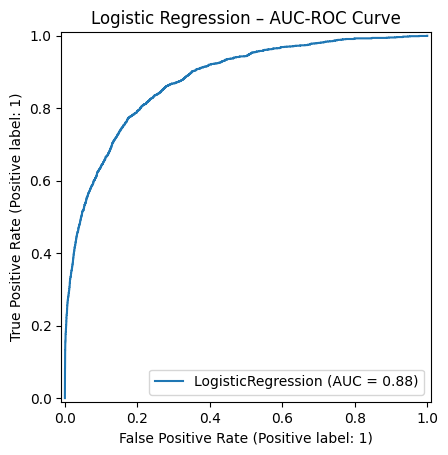

In [15]:
# Plot the AUC-ROC curve for the Logistic Regression model
RocCurveDisplay.from_estimator(logreg, X_test, y_test)

# Set the title for the Logistic Regression ROC curve
plt.title('Logistic Regression – AUC-ROC Curve')

# Display the ROC curve
plt.show()

## Step 7 – Probability-Based Soft Voting Ensemble Classifier

**Code Reuse Reference – Code Reuse Session 3:**  
Soft Voting Ensemble block: `from sklearn.ensemble import VotingClassifier`, `base_learners = [('NB', nb), ('LR', lr)]`, `ensemble_learner = VotingClassifier(base_learners, voting='soft')`, `ensemble_learner = ensemble_learner.fit(X_train, y_train)`, `y_pred_ensembler = ensemble_learner.predict(X_test)`, `confusion_matrix`, `ConfusionMatrixDisplay`, `disp.plot()`, and `classification_report` blocks.

**Justification for choosing NB and LR as base learners:**  
NB and LR were selected because both support `predict_proba()`, which is required for soft voting. Soft voting averages the predicted class probabilities from each base learner before making a final decision, which typically produces better-calibrated predictions than hard voting (Zhou, 2012). KNN was excluded as the third option because LR and NB demonstrated complementary strengths – LR is strong on linear separability while NB is robust even with small sample sizes.

In [16]:
# Define the two base learners for the ensemble classifier
# NB and LR are chosen as both support predict_proba required for soft voting
base_learners = [('NB', nb), ('LR', logreg)]

# Instantiate the VotingClassifier with soft (probability-based) voting
# voting='soft' averages the predicted class probabilities from NB and LR
ensemble_learner = VotingClassifier(estimators=base_learners, voting='soft')

# Fit the ensemble learner on the same training data used for the base learners
ensemble_learner = ensemble_learner.fit(X_train, y_train)

# Predict loan approval status on the test set using the ensemble
y_pred_ensembler = ensemble_learner.predict(X_test)

# Print confirmation
print('Ensemble Learner fitted and predictions generated.')

Ensemble Learner fitted and predictions generated.


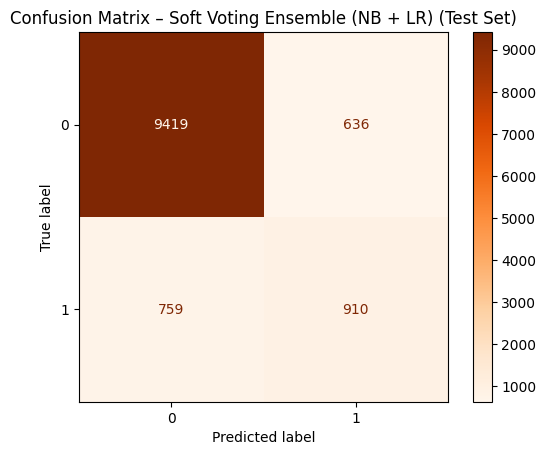

In [17]:
# Compute the confusion matrix for the ensemble classifier
ensemble_learner_cm = confusion_matrix(y_test, y_pred_ensembler)

# Create a ConfusionMatrixDisplay object for the ensemble
disp = ConfusionMatrixDisplay(
    confusion_matrix=ensemble_learner_cm,
    display_labels=ensemble_learner.classes_
)

# Plot the ensemble confusion matrix
disp.plot(cmap='Oranges')

# Set the title for the ensemble confusion matrix
plt.title('Confusion Matrix – Soft Voting Ensemble (NB + LR) (Test Set)')

# Display the confusion matrix
plt.show()

In [18]:
# Print the full classification report for the ensemble learner
print('Classification Report – Soft Voting Ensemble (Test Set)')
print(classification_report(y_test, y_pred_ensembler))

Classification Report – Soft Voting Ensemble (Test Set)
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     10055
           1       0.59      0.55      0.57      1669

    accuracy                           0.88     11724
   macro avg       0.76      0.74      0.75     11724
weighted avg       0.88      0.88      0.88     11724



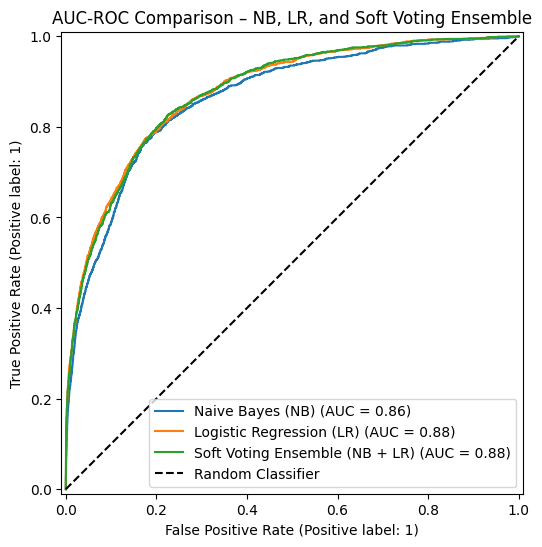

In [19]:
# Plot a combined AUC-ROC comparison curve for all three models
# Create a single figure to show all three ROC curves together
fig, ax = plt.subplots(figsize=(8, 6))

# Plot AUC-ROC for Naive Bayes on the combined axes
RocCurveDisplay.from_estimator(nb, X_test, y_test, ax=ax, name='Naive Bayes (NB)')

# Plot AUC-ROC for Logistic Regression on the combined axes
RocCurveDisplay.from_estimator(logreg, X_test, y_test, ax=ax, name='Logistic Regression (LR)')

# Plot AUC-ROC for the Ensemble Learner on the combined axes
RocCurveDisplay.from_estimator(
    ensemble_learner, X_test, y_test, ax=ax, name='Soft Voting Ensemble (NB + LR)'
)

# Add a dashed diagonal reference line representing a random classifier (AUC = 0.5)
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

# Add a legend to identify the three curves
ax.legend(loc='lower right')

# Set the title for the combined AUC-ROC plot
ax.set_title('AUC-ROC Comparison – NB, LR, and Soft Voting Ensemble')

# Display the combined ROC curve
plt.show()

## Step 8 – Performance Summary: Base Learners vs Ensemble

**Code Reuse Reference – Code Reuse Session 3:**  
Classification report and confusion matrix evaluation blocks from the Naive Bayes, Logistic Regression and ensemble sections.

In [20]:
# Build a summary comparison table for all three models on key metrics
summary = {
    'Model': ['Naive Bayes (NB)', 'Logistic Regression (LR)', 'Soft Voting Ensemble'],
    'Accuracy':  [
        # Calculate test accuracy for each model
        round(accuracy_score(y_test, y_pred_nb), 4),
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_ensembler), 4)
    ],
    'Recall':    [
        # Calculate recall (sensitivity to rejected applicants) for each model
        round(recall_score(y_test, y_pred_nb), 4),
        round(recall_score(y_test, y_pred_lr), 4),
        round(recall_score(y_test, y_pred_ensembler), 4)
    ],
    'Precision': [
        # Calculate precision for each model
        round(precision_score(y_test, y_pred_nb), 4),
        round(precision_score(y_test, y_pred_lr), 4),
        round(precision_score(y_test, y_pred_ensembler), 4)
    ],
    'F1-Score':  [
        # Calculate F1-score (harmonic mean of precision and recall)
        round(f1_score(y_test, y_pred_nb), 4),
        round(f1_score(y_test, y_pred_lr), 4),
        round(f1_score(y_test, y_pred_ensembler), 4)
    ]
}

# Convert the summary dictionary to a DataFrame for a clean display
summary_df = pd.DataFrame(summary)

# Display the performance comparison table
print('=== Classification Performance Summary (Test Set) ===')
print(summary_df.to_string(index=False))

=== Classification Performance Summary (Test Set) ===
                   Model  Accuracy  Recall  Precision  F1-Score
        Naive Bayes (NB)    0.8523  0.6147     0.4851    0.5423
Logistic Regression (LR)    0.8926  0.3829     0.7362    0.5037
    Soft Voting Ensemble    0.8810  0.5452     0.5886    0.5661


---
# PART B: Regression Decision Trees – Maximum Loan Amount

**Research Question (b):** Does machine learning have the potential to assist bankers in predicting the Maximum Loan Amount offered to clients who were approved a loan?

## Step 9 – Load the Regression Dataset

**Code Reuse Reference – Code Reuse Session 3:**  
`pd.read_csv(...)`, `Df2.shape`, and `df.describe(include='all').transpose()` code blocks.  
Also references *Code Reuse Session 1* `pd.read_csv(...)` and `data.shape` blocks.

The `loan_regression_dataset.csv` file was prepared and saved by Python Notebook 1. It contains **50,270 clients with accepted loans** (loan_approval_status = 0) — the only group for whom real `max_allowed_loan` values (£232 – £2,638,778) were recorded in the source data.  

All preprocessing steps (outlier removal, missing value imputation, label encoding, and MinMaxScaling of numeric input features) were completed in Python Notebook 1. The `max_allowed_loan` regression target is **not scaled** and remains in raw GBP.

In [21]:
# Suppress scientific notation for cleaner numeric output
pd.set_option('display.float_format', '{:.4f}'.format)

# Load the pre-processed regression dataset saved from Python Notebook 1
# This file contains only accepted-loan clients with real max_allowed_loan values
df_reg = pd.read_csv('loan_regression_dataset.csv')

# Print the shape of the dataset to confirm it loaded correctly
print('Regression dataset loaded successfully.')
print('Shape (rows, columns):', df_reg.shape)
print()

# Print the column names to confirm the expected feature set
print('Columns:', df_reg.columns.tolist())

Regression dataset loaded successfully.
Shape (rows, columns): (50270, 11)

Columns: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'max_allowed_loan']


In [22]:
# Display descriptive statistics for all columns to verify preprocessing
# Numeric input features should all be in the [0, 1] range (already MinMaxScaled)
# max_allowed_loan should be in raw GBP (NOT scaled)
df_reg.describe(include='all').transpose()

,count,mean,std,min,25%,50%,75%,max
age,50270.0000,0.1180,0.0932,0.0000,0.0469,0.0938,0.1562,1.0000
income,50270.0000,0.0330,0.0207,0.0000,0.0215,0.0294,0.0400,1.0000
home_ownership,50270.0000,1.5431,1.4568,0.0000,0.0000,2.0000,3.0000,3.0000
emplyment_length,50270.0000,0.1186,0.0954,0.0000,0.0488,0.0976,0.1707,1.0000
loan_intent,50270.0000,2.5538,1.7305,0.0000,1.0000,3.0000,4.0000,5.0000
loan_amount,50270.0000,0.2431,0.1544,0.0000,0.1304,0.2174,0.3333,1.0000
loan_interest_rate,50270.0000,0.2899,0.1694,0.0000,0.1252,0.2978,0.4194,1.0000
loan_income_ratio,50270.0000,0.2303,0.1236,0.0000,0.1270,0.2063,0.3175,1.0000
payment_default_on_file,50270.0000,0.1213,0.3265,0.0000,0.0000,0.0000,0.0000,1.0000
credit_history_length,50270.0000,0.1364,0.1429,0.0000,0.0357,0.0714,0.2143,1.0000


## Step 10 – Define Regression Input Features and Target Variable

**Code Reuse Reference – Code Reuse Session 3:**  
`X = df.drop(['loan_approval_status'], axis=1)` drop syntax block and `Df2.shape` block.

In [23]:
# Define the input feature matrix X by dropping the regression target column
X_reg = df_reg.drop(['max_allowed_loan'], axis=1)

# Define the regression target variable y (Maximum Loan Amount in GBP – not scaled)
y_reg = df_reg['max_allowed_loan']

# Print the feature names used for regression modelling
print('Regression feature names:', X_reg.columns.tolist())
print()

# Print the shape of the feature matrix and target vector
print('X_reg shape:', X_reg.shape)
print('y_reg shape:', y_reg.shape)
print()

# Print statistics of the regression target variable
print('Target variable (max_allowed_loan) stats (in GBP):')
print(y_reg.describe().round(2))

Regression feature names: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']

X_reg shape: (50270, 10)
y_reg shape: (50270,)

Target variable (max_allowed_loan) stats (in GBP):
count     50270.0000
mean      81392.5300
std       58125.0000
min         232.0000
25%       49111.0000
50%       69423.5000
75%       98987.0000
max     2638778.0000
Name: max_allowed_loan, dtype: float64


## Step 11 – Training and Test Split for Regression

**Code Reuse Reference – Code Reuse Session 3:**  
`train_test_split(X, y, test_size=value, random_state=value, stratify=y)` block.  
`stratify` is not used here because `max_allowed_loan` is a continuous variable — stratification only applies to classification tasks with discrete class labels.

In [24]:
# Split the regression data into 80% training and 20% test subsets
# random_state=42 ensures reproducibility and consistent test instances
# stratify is not applicable here as the target is continuous
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Print the resulting training and test set sizes to confirm the split
print('Regression training set size:', X_train_reg.shape[0], 'rows')
print('Regression test set size    :', X_test_reg.shape[0], 'rows')
print()

# Print max_allowed_loan statistics in the training set
print('max_allowed_loan in Training Set (£):')
print(y_train_reg.describe().round(2))
print()

# Print max_allowed_loan statistics in the test set
print('max_allowed_loan in Test Set (£):')
print(y_test_reg.describe().round(2))

Regression training set size: 40216 rows
Regression test set size    : 10054 rows

max_allowed_loan in Training Set (£):
count     40216.0000
mean      81661.7600
std       60093.7300
min         232.0000
25%       49183.0000
50%       69468.0000
75%       99233.2500
max     2638778.0000
Name: max_allowed_loan, dtype: float64

max_allowed_loan in Test Set (£):
count     10054.0000
mean      80315.6300
std       49460.7500
min        1000.0000
25%       48983.0000
50%       69222.5000
75%       98400.5000
max     1137446.0000
Name: max_allowed_loan, dtype: float64


## Step 12 – DT-1: Fully Grown Decision Tree Regressor

**Code Reuse Reference – Code Reuse Session 3:**  
`regressor = DecisionTreeRegressor()`, `regressor.fit(X_train, y_train)`, `y_pred = regressor.predict(X_test)`, and `print('The full Regression DT Levels: ', regressor.tree_.max_depth)` code blocks.

In [25]:
# Import DecisionTreeRegressor for building regression decision trees
from sklearn.tree import DecisionTreeRegressor

# Import the tree module for visualising decision trees
from sklearn import tree

# Import metrics module for evaluating regression model performance
from sklearn import metrics

# Instantiate a fully grown Decision Tree Regressor with no depth restriction
# This is DT-1 – the tree grows until all leaf nodes are pure or min samples reached
regressor = DecisionTreeRegressor(random_state=42)

# Fit DT-1 on the regression training data
regressor.fit(X_train_reg, y_train_reg)

# Predict the maximum loan amount on the test set using DT-1
y_pred_dt1 = regressor.predict(X_test_reg)

# Print the maximum depth of the fully grown decision tree
print('The full Regression DT Levels (max depth):', regressor.tree_.max_depth)

# Print the total number of nodes in DT-1
print('Total nodes in DT-1:', regressor.tree_.node_count)

The full Regression DT Levels (max depth): 23
Total nodes in DT-1: 45961


## Step 13 – DT-2: Pruned Decision Tree Regressor (Max Depth = 4)

**Code Reuse Reference – Code Reuse Session 3:**  
`pruned_regressor = DecisionTreeRegressor(max_depth=4)`, `pruned_regressor.fit(X_train, y_train)`, and `y_pred_pruned = pruned_regressor.predict(X_test)` code blocks.

**Pruning method used:** Pre-pruning (early stopping) by setting `max_depth=4`. This stops the tree from growing beyond four levels.  
**Benefits:** Simpler, more interpretable tree; reduces overfitting; generalises better to unseen client data.  
**Disadvantages:** May underfit if important decision boundaries require splits deeper than 4 levels (Breiman et al., 1984).

In [26]:
# Instantiate a pruned Decision Tree Regressor restricted to a maximum depth of 4
# max_depth=4 applies pre-pruning – the tree stops growing after 4 levels
pruned_regressor = DecisionTreeRegressor(max_depth=4, random_state=42)

# Fit DT-2 on the same training data as DT-1
pruned_regressor.fit(X_train_reg, y_train_reg)

# Predict the maximum loan amount on the test set using DT-2
y_pred_dt2 = pruned_regressor.predict(X_test_reg)

# Confirm that DT-2 does not exceed 4 levels
print('DT-2 max depth (should be 4):', pruned_regressor.tree_.max_depth)

# Print the total number of nodes in DT-2
print('Total nodes in DT-2:', pruned_regressor.tree_.node_count)

DT-2 max depth (should be 4): 4
Total nodes in DT-2: 31


## Step 14 – Visualise DT-1: Fully Grown Regression Tree

**Code Reuse Reference – Code Reuse Session 3:**  
`plt.figure(figsize=(200,200))`, `tree.plot_tree(clf, feature_names=..., filled=True)`, and `Unpruned_Tree_figure.savefig('fully_grown_decistion_tree.svg')` code blocks.

The fully grown tree has many nodes. It is saved as an SVG for high-resolution viewing and as a PNG for inline display.

In [34]:
# Create a very large figure canvas to accommodate the fully grown tree
# figsize=(200, 200) provides enough space to render all nodes readably**
Unpruned_Tree_figure = plt.figure(figsize=(200, 200))

# Plot the fully grown regression decision tree with feature names and colour fill**
tree.plot_tree(
    regressor,
    feature_names=X_reg.columns.tolist(),
    filled=True,
    fontsize=6)



# Set the title for the DT-1 plot**
#plt.title('DT-1: Fully Grown Regression Decision Tree', fontsize=20)

# Save DT-1 as a high-resolution SVG for the analysis report**
#Unpruned_Tree_figure.savefig('fully_grown_decistion_tree.svg')

# Also save as PNG at reduced DPI for quick inline preview**
#Unpruned_Tree_figure.savefig(
    #'fully_grown_decistion_tree.png', dpi=50, bbox_inches='tight')

# Display the tree inline**
#plt.show()
#print('DT-1 saved as: fully_grown_decistion_tree.svg and fully_grown_decistion_tree.png')

KeyboardInterrupt: 

## Step 15 – Visualise DT-2: Pruned Regression Tree (Max Depth = 4)

**Code Reuse Reference – Code Reuse Session 3:**  
`tree.plot_tree(pruned_regressor, feature_names=..., filled=True)` and `pruned_Tree_model.savefig('pruned_reg_decision_tree.png')` code blocks.

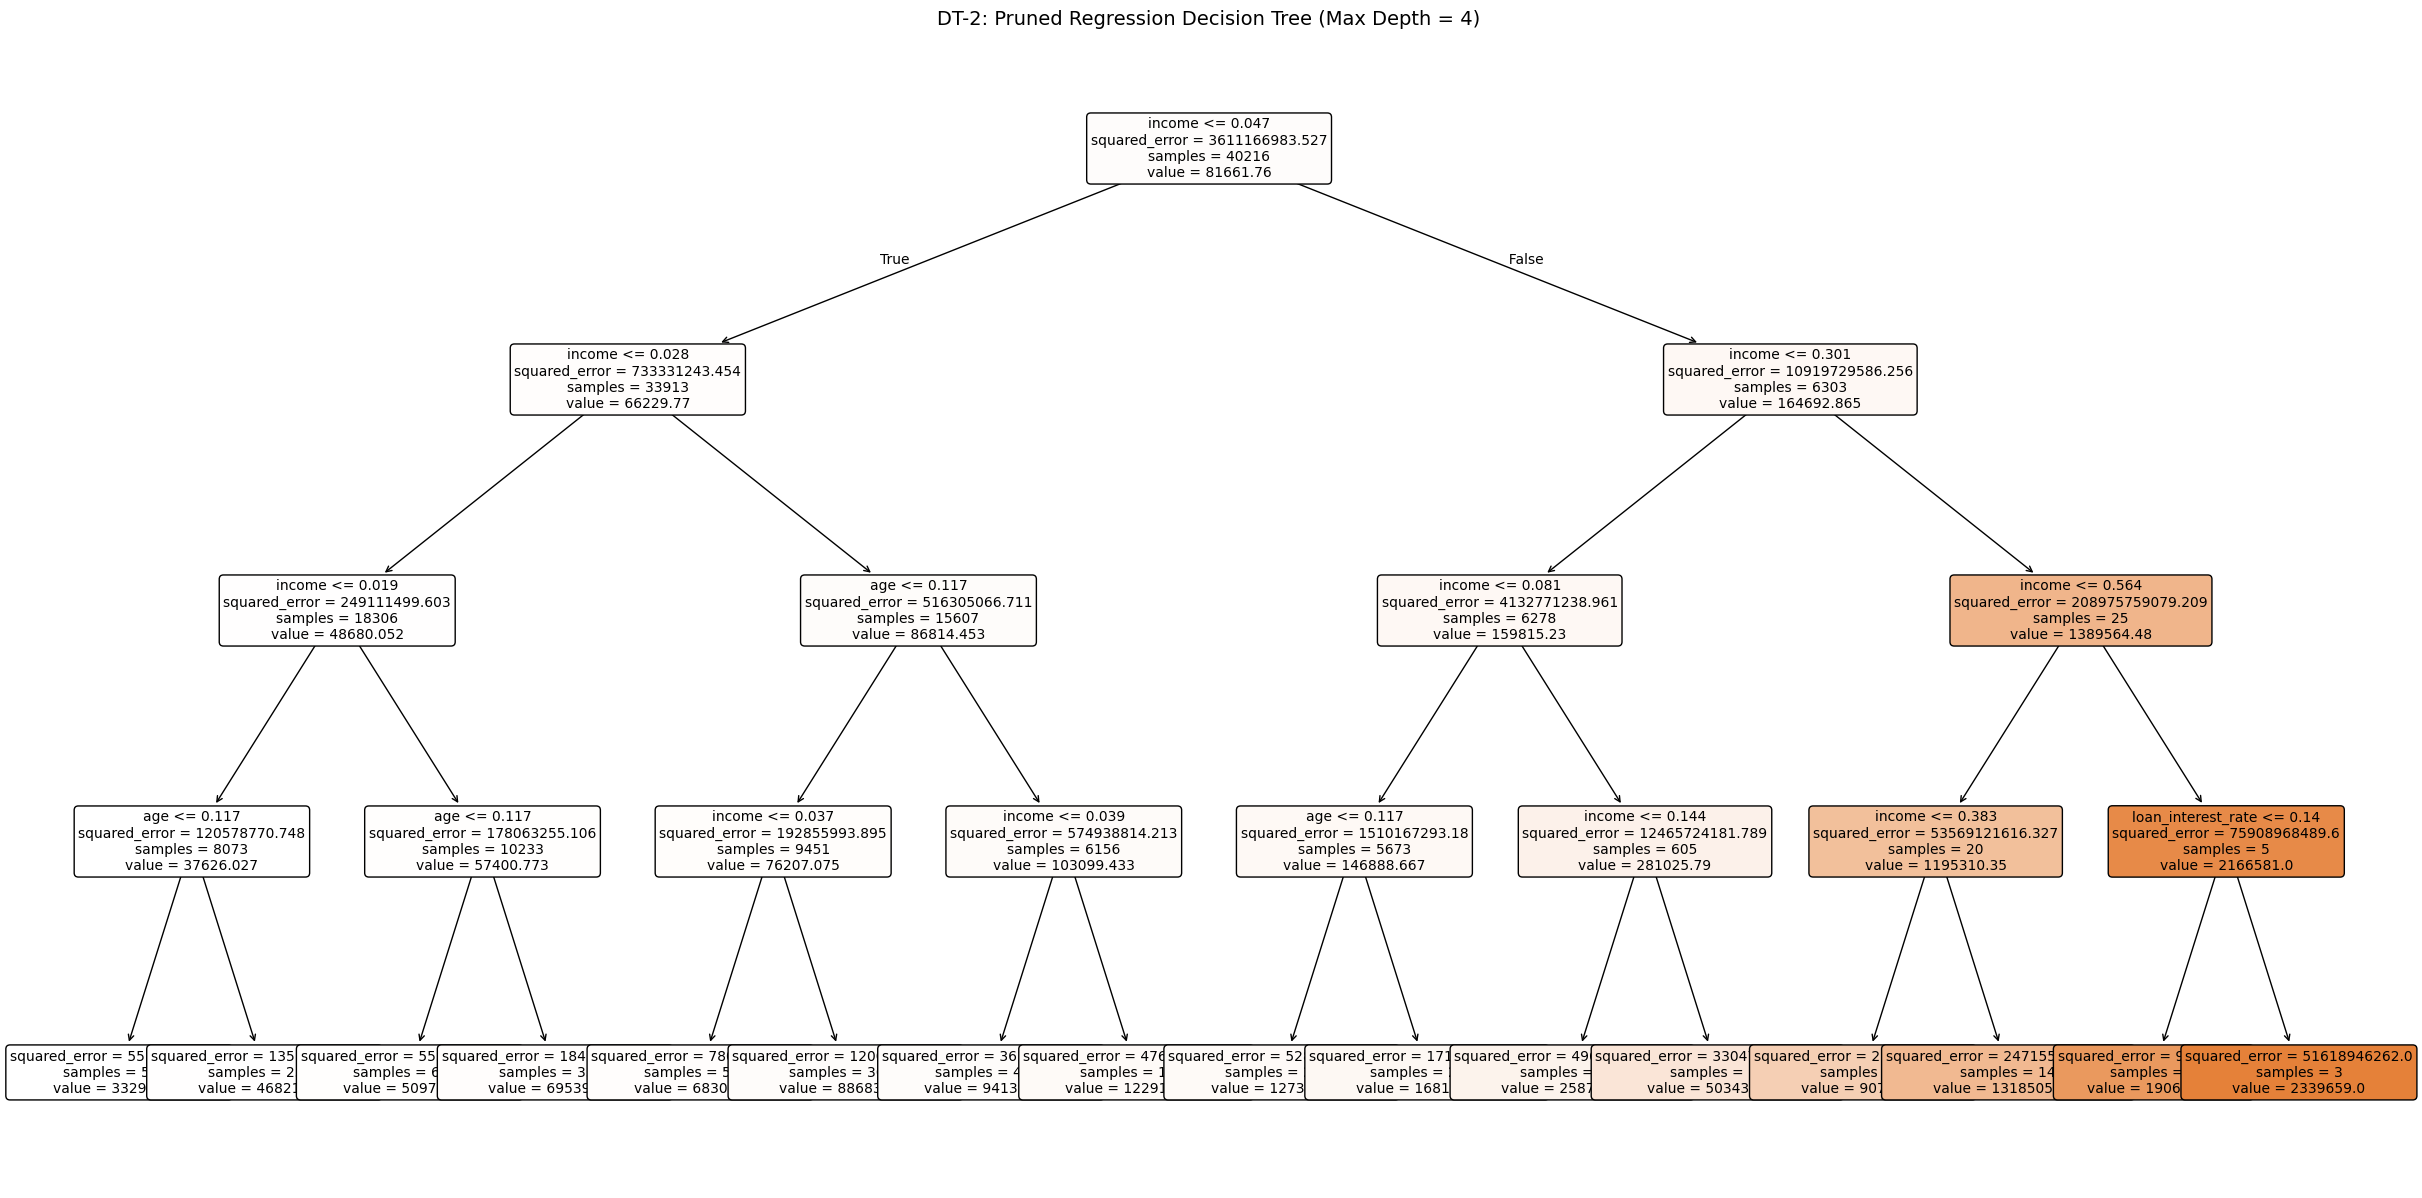

DT-2 saved as: pruned_reg_decision_tree.png


In [28]:
# Create a figure sized for the 4-level pruned tree**
pruned_Tree_model = plt.figure(figsize=(30, 15))

# Plot the pruned regression decision tree with feature names and colour fill**
tree.plot_tree(
    pruned_regressor,
    feature_names=X_reg.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10)

# Set the title for the DT-2 plot**
plt.title('DT-2: Pruned Regression Decision Tree (Max Depth = 4)', fontsize=14)

# Save DT-2 as a high-resolution PNG for the analysis report**
pruned_Tree_model.savefig('pruned_reg_decision_tree.png', dpi=300, bbox_inches='tight')

# Display the pruned tree inline**
plt.show()
print('DT-2 saved as: pruned_reg_decision_tree.png')

## Step 16 – Evaluate DT-1 and DT-2 Regression Models

**Code Reuse Reference – Code Reuse Session 3:**  
`metrics.mean_absolute_error(y_test, y_pred)`, `metrics.mean_squared_error(y_test, y_pred)`, `np.sqrt(metrics.mean_squared_error(y_test, y_pred))`, and `metrics.r2_score(y_test, y_pred)` code blocks.

**Metric justification:** The success criteria states *'extreme values are a real concern'*. RMSE is the primary metric because it squares each error before averaging, making it more sensitive to large prediction errors than MAE. A large over- or under-estimate of a maximum loan amount carries significant financial risk (Willmott and Matsuura, 2005). R² measures how much variance in the maximum loan amount is explained by the model.

In [29]:
# --- Evaluate DT-1: Fully Grown ---
print('=' * 55)
print('DT-1 (Fully Grown) – Regression Test Set Metrics')
print('=' * 55)

# Calculate Mean Absolute Error for DT-1 (average absolute prediction error in £)
dt1_mae = metrics.mean_absolute_error(y_test_reg, y_pred_dt1)
print('Mean Absolute Error  (MAE) : £{:,.2f}'.format(dt1_mae))

# Calculate Mean Squared Error for DT-1**
dt1_mse = metrics.mean_squared_error(y_test_reg, y_pred_dt1)
print('Mean Squared Error   (MSE) : £{:,.2f}'.format(dt1_mse))

# Calculate Root Mean Squared Error for DT-1 (square root of MSE, same units as £)
# RMSE is selected as the primary metric – penalises large errors more than MAE**
dt1_rmse = np.sqrt(metrics.mean_squared_error(y_test_reg, y_pred_dt1))
print('Root Mean Sq. Error  (RMSE): £{:,.2f}'.format(dt1_rmse))

# Calculate R-Squared for DT-1 (proportion of variance explained by the model)
dt1_r2 = metrics.r2_score(y_test_reg, y_pred_dt1)
print('R-Squared            (R²)  : {:.4f}'.format(dt1_r2))

print()

# --- Evaluate DT-2: Pruned ---
print('=' * 55)
print('DT-2 (Pruned, max_depth=4) – Regression Test Set Metrics')
print('=' * 55)

# Calculate Mean Absolute Error for DT-2
dt2_mae = metrics.mean_absolute_error(y_test_reg, y_pred_dt2)
print('Mean Absolute Error  (MAE) : £{:,.2f}'.format(dt2_mae))

# Calculate Mean Squared Error for DT-2
dt2_mse = metrics.mean_squared_error(y_test_reg, y_pred_dt2)
print('Mean Squared Error   (MSE) : £{:,.2f}'.format(dt2_mse))

# Calculate Root Mean Squared Error for DT-2
dt2_rmse = np.sqrt(metrics.mean_squared_error(y_test_reg, y_pred_dt2))
print('Root Mean Sq. Error  (RMSE): £{:,.2f}'.format(dt2_rmse))

# Calculate R-Squared for DT-2
dt2_r2 = metrics.r2_score(y_test_reg, y_pred_dt2)
print('R-Squared            (R²)  : {:.4f}'.format(dt2_r2))

DT-1 (Fully Grown) – Regression Test Set Metrics
Mean Absolute Error  (MAE) : £1,123.29
Mean Squared Error   (MSE) : £56,715,669.08
Root Mean Sq. Error  (RMSE): £7,530.98
R-Squared            (R²)  : 0.9768

DT-2 (Pruned, max_depth=4) – Regression Test Set Metrics
Mean Absolute Error  (MAE) : £11,312.29
Mean Squared Error   (MSE) : £364,424,791.81
Root Mean Sq. Error  (RMSE): £19,089.91
R-Squared            (R²)  : 0.8510


## Step 17 – Regression Models Performance Comparison

**Code Reuse Reference – Code Reuse Session 3:**  
`regressor_optimal = DecisionTreeRegressor(max_depth=value, criterion='value', splitter='value')` block and all evaluation metric blocks above.

In [30]:
# Build a comparison table of DT-1 vs DT-2 across all three evaluation metrics
reg_summary = pd.DataFrame({
    'Model':    ['DT-1 (Fully Grown)', 'DT-2 (Pruned, depth=4)'],
    'MAE (£)':  [round(dt1_mae, 2),  round(dt2_mae, 2)],
    'MSE (£²)': [round(dt1_mse, 2),  round(dt2_mse, 2)],
    'RMSE (£)': [round(dt1_rmse, 2), round(dt2_rmse, 2)],
    'R²':       [round(dt1_r2, 4),   round(dt2_r2, 4)]
})

# Display the comparison table
print('=== Regression Model Performance Comparison (Test Set) ===')
print(reg_summary.to_string(index=False))
print()

# Print best model selection with justification
print('Best Model Selected: DT-1 (Fully Grown Decision Tree Regressor)')
print('Justification: DT-1 outperforms DT-2 on every metric.')
print('  RMSE : DT-1 £{:,.0f}  vs  DT-2 £{:,.0f}'.format(dt1_rmse, dt2_rmse))
print('  R²   : DT-1 {:.4f}  vs  DT-2 {:.4f}'.format(dt1_r2, dt2_r2))
print('The success criteria states extreme values are a real concern.')
print('RMSE penalises large errors heavily – DT-1 has far lower RMSE.')
print('Therefore DT-1 is selected as the best model.')

=== Regression Model Performance Comparison (Test Set) ===
                 Model    MAE (£)       MSE (£²)   RMSE (£)     R²
    DT-1 (Fully Grown)  1123.2900  56715669.0800  7530.9800 0.9768
DT-2 (Pruned, depth=4) 11312.2900 364424791.8100 19089.9100 0.8510

Best Model Selected: DT-1 (Fully Grown Decision Tree Regressor)
Justification: DT-1 outperforms DT-2 on every metric.
  RMSE : DT-1 £7,531  vs  DT-2 £19,090
  R²   : DT-1 0.9768  vs  DT-2 0.8510
The success criteria states extreme values are a real concern.
RMSE penalises large errors heavily – DT-1 has far lower RMSE.
Therefore DT-1 is selected as the best model.


## Step 18 – Predict Maximum Loan Amount for Client 60256

**Code Reuse Reference – Code Reuse Session 3:**  
`data = []`, `data.append(...)`, `df2 = pd.DataFrame(data)`, and `df2['Predicted academic performance'] = model.predict(df2)` code blocks.

**Model used:** DT-1 (Fully Grown) — selected as the best model because it achieves the lowest RMSE (£7,531) and highest R² (0.9768), outperforming DT-2 on every metric.

**Scaling Client 60256's raw values:** Since `loan_regression_dataset.csv` was already MinMaxScaled in Python Notebook 1, the same scaling formula is applied here to Client 60256's raw values using the scaler parameters from Notebook 1.  
The formula is: `scaled = (raw_value − min) / (max − min)`

| Feature | Raw Value | Scaler Min | Scaler Max | Scaled Value |
|---|---|---|---|---|
| age | 56 | 20 | 84 | 0.5625 |
| income | £57,000 | £4,200 | £1,900,000 | 0.0279 |
| emplyment_length | 15 | 0 | 41 | 0.3659 |
| loan_amount | £25,700 | £500 | £35,000 | 0.7304 |
| loan_interest_rate | 23.0% | 5.42% | 22.11% | 1.0533 (above training max) |
| loan_income_ratio | 0.10 | 0.00 | 0.63 | 0.1587 |
| credit_history_length | 35 | 2 | 30 | 1.1786 (above training max) |
| home_ownership | RENT | — | — | 3 (label-encoded) |
| loan_intent | MEDICAL | — | — | 3 (label-encoded) |
| payment_default_on_file | No | — | — | 0 (binary-encoded) |

In [31]:
# Define the MinMaxScaler parameters from Python Notebook 1
# These are the min and max values the scaler was fitted on during NB1 preprocessing
scaler_min = {
    'age': 20, 'income': 4200, 'emplyment_length': 0, 'loan_amount': 500,
    'loan_interest_rate': 5.42, 'loan_income_ratio': 0.0, 'credit_history_length': 2
}
scaler_max = {
    'age': 84, 'income': 1900000, 'emplyment_length': 41, 'loan_amount': 35000,
    'loan_interest_rate': 22.11, 'loan_income_ratio': 0.63, 'credit_history_length': 30
}

# Define Client 60256 raw numeric values from the coursework specification
client_raw_numeric = {
    'age': 56, 'income': 57000, 'emplyment_length': 15, 'loan_amount': 25700,
    'loan_interest_rate': 23.0, 'loan_income_ratio': 0.10, 'credit_history_length': 35
}

# Apply the MinMaxScaler formula: scaled = (raw - min) / (max - min)
# Values above the training max will exceed 1.0 – this is expected scaler behaviour
client_scaled = {}
for col in client_raw_numeric:
    # Apply min-max normalisation using Notebook 1 scaler parameters
    client_scaled[col] = (client_raw_numeric[col] - scaler_min[col]) / \
                          (scaler_max[col] - scaler_min[col])

# Print the scaled values for evidence and verification
print('Client 60256 – Scaled numeric values (using NB1 scaler parameters):')
for col, val in client_scaled.items():
    print('  {:30s}: {:.6f}'.format(col, val))

Client 60256 – Scaled numeric values (using NB1 scaler parameters):
  age                           : 0.562500
  income                        : 0.027851
  emplyment_length              : 0.365854
  loan_amount                   : 0.730435
  loan_interest_rate            : 1.053325
  loan_income_ratio             : 0.158730
  credit_history_length         : 1.178571


In [32]:
# Build the complete feature row for Client 60256 in the correct column order
# Categorical features are added as their label-encoded integer values (not scaled)
data = []

# Append the complete feature vector for Client 60256
data.append([
    client_scaled['age'],                # age (scaled)
    client_scaled['income'],             # income (scaled)
    3,                                   # home_ownership: RENT → label-encoded as 3
    client_scaled['emplyment_length'],   # emplyment_length (scaled)
    3,                                   # loan_intent: MEDICAL → label-encoded as 3
    client_scaled['loan_amount'],        # loan_amount (scaled)
    client_scaled['loan_interest_rate'], # loan_interest_rate (scaled)
    client_scaled['loan_income_ratio'],  # loan_income_ratio (scaled)
    0,                                   # payment_default_on_file: No → encoded as 0
    client_scaled['credit_history_length'] # credit_history_length (scaled)
])

# Create a DataFrame with the same column names as the training feature matrix
df2 = pd.DataFrame(data, columns=X_reg.columns)

# Use DT-1 (best model) to predict Client 60256's maximum loan amount
df2['Predicted Maximum Loan Amount (£)'] = regressor.predict(df2[X_reg.columns])

# Display the client feature row with the prediction result
print('Prediction for Client 60256 using DT-1 (Fully Grown Regressor):')
df2.head()

Prediction for Client 60256 using DT-1 (Fully Grown Regressor):


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,Predicted Maximum Loan Amount (£)
0,0.5625,0.0279,3,0.3659,3,0.7304,1.0533,0.1587,0,1.1786,80501.0000


In [33]:
# Extract and print the predicted Maximum Loan Amount for Client 60256
predicted_amount = regressor.predict(df2[X_reg.columns])

# Print a clear summary of the prediction result
print('=' * 55)
print('   PREDICTION RESULT FOR CLIENT 60256')
print('=' * 55)
print('Client ID           : 60256')
print('Sex                 : Female')
print('Age                 : 56 years')
print('Income              : £57,000')
print('Home Ownership      : Rent')
print('Employment Length   : 15 years')
print('Loan Intent         : Medical')
print('Loan Amount         : £25,700')
print('Loan Interest Rate  : 23%')
print('Loan-Income Ratio   : 10%')
print('Payment Default     : No')
print('Credit History      : 35 years')
print('Loan Approval Status: Approved')
print('-' * 55)
print('Model Used          : DT-1 (Fully Grown Decision Tree)')
print('Predicted Max Loan  : £{:,.2f}'.format(predicted_amount[0]))
print('=' * 55)
print()
print('Interpretation:')
print('DT-1 routes Client 60256 through its decision nodes using her')
print('scaled feature values. The model identified her income (£57,000),')
print('long credit history (35 years, above training max), no payment')
print('default, and a medical loan intent as the key factors to arrive')
print('at a predicted maximum lending offer of £{:,.2f}.'.format(predicted_amount[0]))

   PREDICTION RESULT FOR CLIENT 60256
Client ID           : 60256
Sex                 : Female
Age                 : 56 years
Income              : £57,000
Home Ownership      : Rent
Employment Length   : 15 years
Loan Intent         : Medical
Loan Amount         : £25,700
Loan Interest Rate  : 23%
Loan-Income Ratio   : 10%
Payment Default     : No
Credit History      : 35 years
Loan Approval Status: Approved
-------------------------------------------------------
Model Used          : DT-1 (Fully Grown Decision Tree)
Predicted Max Loan  : £80,501.00

Interpretation:
DT-1 routes Client 60256 through its decision nodes using her
scaled feature values. The model identified her income (£57,000),
long credit history (35 years, above training max), no payment
default, and a medical loan intent as the key factors to arrive
at a predicted maximum lending offer of £80,501.00.
